First 5 Rows
  Case Number         Date    Year        Type    Country             Area  \
0  2018.06.25  25-Jun-2018  2018.0     Boating        USA       California   
1  2018.06.18  18-Jun-2018  2018.0  Unprovoked        USA          Georgia   
2  2018.06.09  09-Jun-2018  2018.0     Invalid        USA           Hawaii   
3  2018.06.08  08-Jun-2018  2018.0  Unprovoked  AUSTRALIA  New South Wales   
4  2018.06.04  04-Jun-2018  2018.0    Provoked     MEXICO           Colima   

                         Location     Activity             Name Sex   ...  \
0     Oceanside, San Diego County     Paddling      Julie Wolfe    F  ...   
1  St. Simon Island, Glynn County     Standing  Adyson McNeely     F  ...   
2                    Habush, Oahu      Surfing      John Denges    M  ...   
3              Arrawarra Headland      Surfing             male    M  ...   
4                        La Ticla  Free diving   Gustavo Ramos     M  ...   

          Species           Investigator or Source     

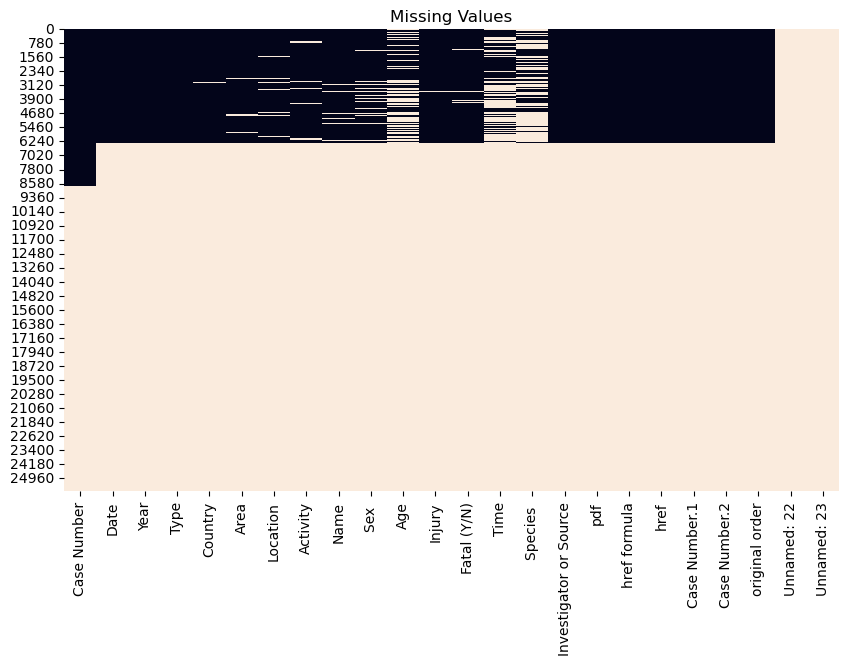


Missing Values After Filling
Case Number               0
Date                      0
Year                      0
Type                      0
Country                   0
Area                      0
Location                  0
Activity                  0
Name                      0
Sex                       0
Age                       0
Injury                    0
Fatal (Y/N)               0
Time                      0
Species                   0
Investigator or Source    0
pdf                       0
href formula              0
href                      0
Case Number.1             0
Case Number.2             0
original order            0
Unnamed: 22               0
Unnamed: 23               0
dtype: int64

Duplicate Rows = 19412
Shape after removing duplicates
(6311, 24)
Case Number                object
Date                       object
Year                      float64
Type                       object
Country                    object
Area                       object
Location      

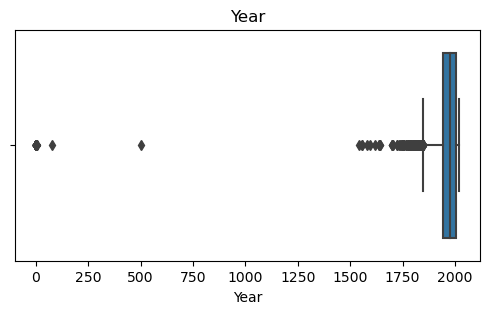

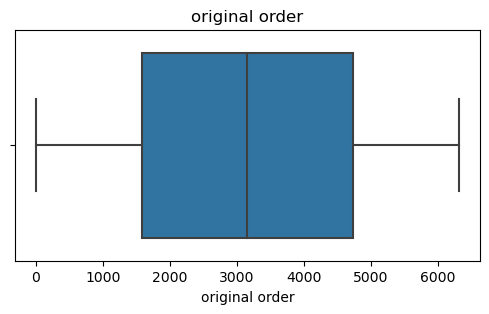

Shape after removing outliers
(6050, 22)


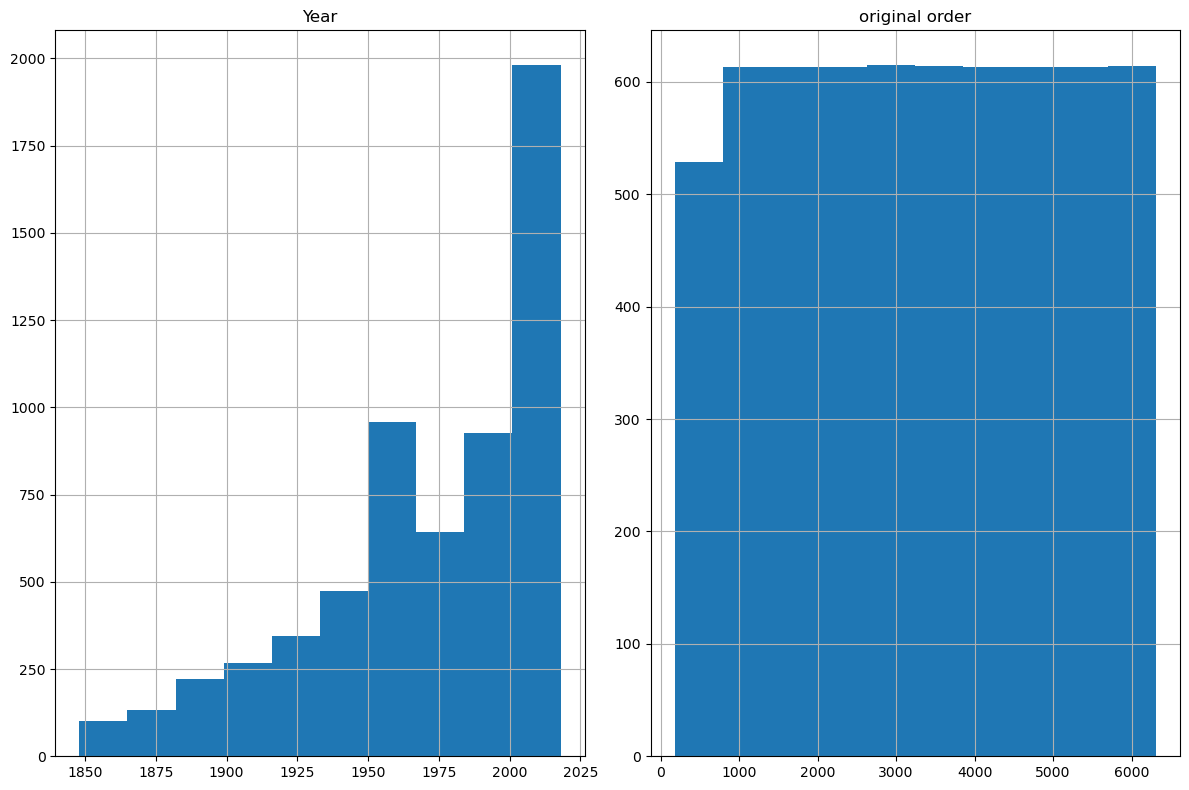

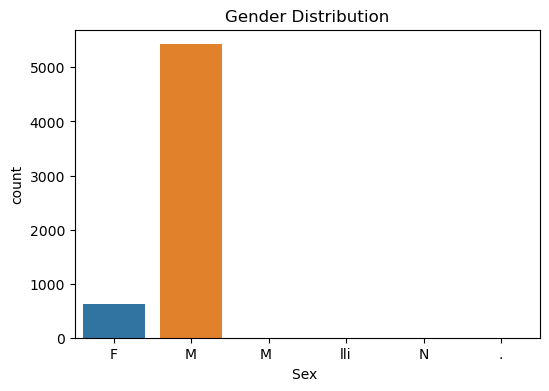

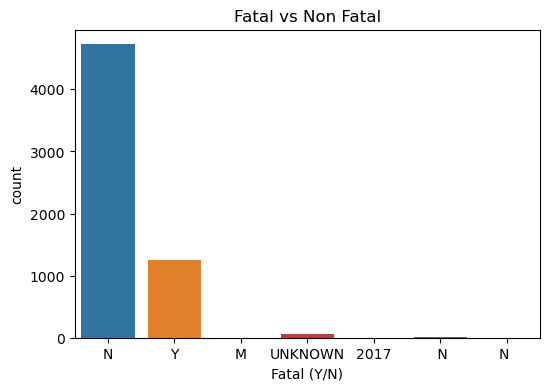

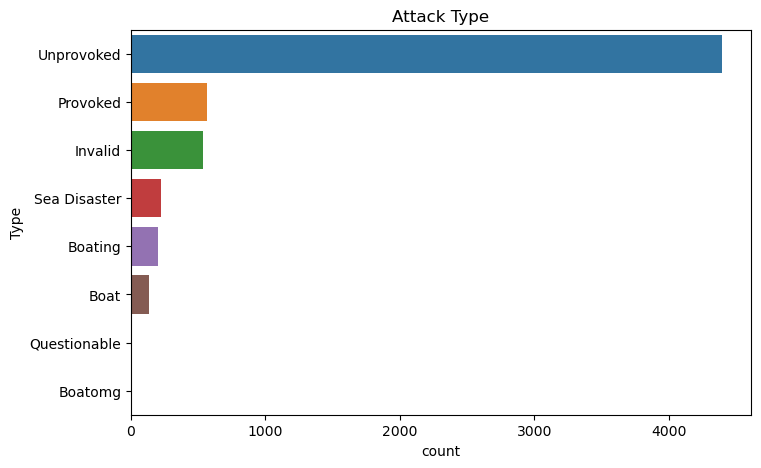

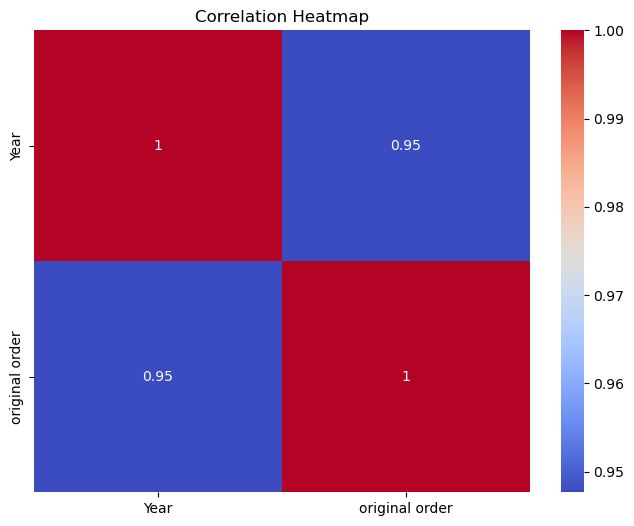


Normalized Dataset
   Case Number  Date  Year  Type  Country  Area  Location  Activity  Name  \
0         6024  3545   1.0     1      188   150      2442       796  2567   
1         6023  2458   1.0     7      188   265      3465      1070   271   
2         6022  1212   1.0     3      188   302      1316      1112  2353   
3         6021  1075   1.0     7       11   472       294      1112  4962   
4         6020   554   1.0     4      101   186      1736       556  1813   

   Sex   ...  Fatal (Y/N)  Time  Species   Investigator or Source   pdf  \
0     1  ...            3   256      1267                    3190  6029   
1     1  ...            3   178      1267                    2120  6028   
2     2  ...            3    50      1267                    2120  6027   
3     2  ...            3   313       231                     379  6026   
4     2  ...            3   313      1212                      54  6025   

   href formula  href  Case Number.1  Case Number.2  original orde

In [1]:
# ==========================================================
# DATA PREPROCESSING & EDA - Shark Attacks Dataset
# ==========================================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------
# Load Dataset
# ----------------------------------------------------------

path = r"C:\Users\AI_LAB\Downloads\attacks.csv"

# Dataset uses Latin-1 encoding
df = pd.read_csv(path, encoding="latin1")

# ----------------------------------------------------------
# Display Dataset
# ----------------------------------------------------------

print("First 5 Rows")
print(df.head())

print("\nLast 5 Rows")
print(df.tail())

print("\nShape of Dataset")
print(df.shape)

print("\nColumns")
print(df.columns)

print("\nInformation")
df.info()

print("\nStatistical Summary")
print(df.describe(include='all'))

# ----------------------------------------------------------
# Missing Values
# ----------------------------------------------------------

print("\nMissing Values")
print(df.isnull().sum())

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

# ----------------------------------------------------------
# Fill Missing Values
# ----------------------------------------------------------

for col in df.select_dtypes(include=['object']):
    df[col] = df[col].fillna(df[col].mode()[0])

for col in df.select_dtypes(include=['int64','float64']):
    df[col] = df[col].fillna(df[col].median())

print("\nMissing Values After Filling")
print(df.isnull().sum())

# ----------------------------------------------------------
# Duplicate Records
# ----------------------------------------------------------

print("\nDuplicate Rows =", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Shape after removing duplicates")
print(df.shape)

# ----------------------------------------------------------
# Remove Empty Columns
# ----------------------------------------------------------

df.drop(columns=["Unnamed: 22","Unnamed: 23"], inplace=True, errors="ignore")

# ----------------------------------------------------------
# Data Types
# ----------------------------------------------------------

print(df.dtypes)

# ----------------------------------------------------------
# Boxplots (Outlier Detection)
# ----------------------------------------------------------

num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:

    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

# ----------------------------------------------------------
# Remove Outliers using IQR
# ----------------------------------------------------------

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("Shape after removing outliers")
print(df.shape)

# ----------------------------------------------------------
# Histograms
# ----------------------------------------------------------

df[num_cols].hist(figsize=(12,8))
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# Count Plots
# ----------------------------------------------------------

plt.figure(figsize=(6,4))
sns.countplot(x="Sex ", data=df)
plt.title("Gender Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="Fatal (Y/N)", data=df)
plt.title("Fatal vs Non Fatal")
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(y="Type", data=df,
              order=df["Type"].value_counts().index)
plt.title("Attack Type")
plt.show()

# ----------------------------------------------------------
# Correlation Matrix
# ----------------------------------------------------------

plt.figure(figsize=(8,6))

sns.heatmap(df[num_cols].corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

# ----------------------------------------------------------
# Label Encoding
# ----------------------------------------------------------

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col].astype(str))

# ----------------------------------------------------------
# Min-Max Normalization
# ----------------------------------------------------------

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])

print("\nNormalized Dataset")
print(df.head())

# ----------------------------------------------------------
# Final Dataset
# ----------------------------------------------------------

print(df.info())

print(df.head())